# Aditya-L1 MAG L2 Data Characterization

## 1. Overview

### 1.1 Objective

Characterize the Aditya-L1 Magnetometer (MAG) Level-2 dataset prior to
large-scale scientific analysis. This notebook establishes the structure,
temporal coverage, data quality, and statistical properties of the
interplanetary magnetic field measurements contained in the L2 files.

### 1.2 Dataset scope

The characterization covers all Level-2 (L2) MAG files available in the
local raw-data directory, spanning the full range of dates present on disk.
Both GSE and GSM magnetic-field components are inventoried, with GSE
components used as the primary basis for the quantitative analysis below.

### 1.3 Analysis questions

- How many L2 files are available, and what temporal range do they cover?
- What is the structure (dimensions, variables, attributes) of a single L2 file?
- What is the sampling cadence, and how consistent is it?
- What fraction of the data is flagged valid, and where — and for how long — are the invalid intervals?
- What are the statistical properties of the magnetic-field components and magnitude?
- Is the dataset, in its current state, ready for downstream scientific analysis?

### 1.4 Dataset / file being characterized

**Mission:** Aditya-L1
**Instrument:** Magnetometer (MAG)
**Level:** L2 (calibrated, quality-flagged)
**Format:** NetCDF (`.nc`)
**Coordinate system:** GSE (primary), GSM (inventoried)
**Units:** nT
**Time reference:** UTC
**Nominal cadence:** 10 s

## 2. Environment and Configuration

### 2.1 Imports

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

### 2.2 Paths

In [2]:
DATA_DIR = Path("../data/raw/L2")
FILE_PATTERN = "*.nc"

files = sorted(DATA_DIR.glob(FILE_PATTERN))

assert len(files) > 0, f"No L2 files found in {DATA_DIR} matching {FILE_PATTERN!r}"

### 2.3 Analysis configuration

In [3]:
NETCDF_ENGINE = "h5netcdf"

FILL_VALUE = -9999.0
QUALITY_VALID = 1
QUALITY_INVALID = 0

NOMINAL_CADENCE = pd.Timedelta(seconds=10)
GAP_THRESHOLD = 5 * NOMINAL_CADENCE

GSE_COMPONENTS = ["Bx_gse", "By_gse", "Bz_gse"]
GSM_COMPONENTS = ["Bx_gsm", "By_gsm", "Bz_gsm"]
QUALITY_VAR = "Quality_flag_10s_data"
TIME_VAR = "time"

PERCENTILES = [1, 5, 25, 50, 75, 95, 99]

plt.rcParams["figure.figsize"] = (15, 4)

### 2.4 Coordinate and unit conventions

To avoid ambiguity later in the notebook, the conventions used throughout
are stated explicitly here:

```
Coordinate system: GSE (primary analysis frame), GSM (inventoried only)
Field units:        nT
Time reference:     UTC
Nominal sampling:   10 s
```

## 3. Dataset Inventory

### 3.1 Number of L2 files

In [4]:
print(f"Number of L2 files: {len(files)}")

Number of L2 files: 91


### 3.2 File naming / ordering

In [5]:
for f in files[:5]:
    print(f.name)

if len(files) > 5:
    print("...")
    print(files[-1].name)

L2_AL1_MAG_20260410_V00.nc
L2_AL1_MAG_20260411_V00.nc
L2_AL1_MAG_20260412_V00.nc
L2_AL1_MAG_20260413_V00.nc
L2_AL1_MAG_20260414_V00.nc
...
L2_AL1_MAG_20260803_V00.nc


### 3.3 Temporal coverage across files

In [6]:
def file_time_bounds(path):
    with xr.open_dataset(path, engine=NETCDF_ENGINE) as ds:
        time = pd.to_datetime(ds[TIME_VAR].values, unit="s", utc=True)
        return time[0], time[-1], len(time)


file_records = []
for f in files:
    start, end, n_obs = file_time_bounds(f)
    file_records.append(
        {
            "file": f.name,
            "start": start,
            "end": end,
            "n_obs": n_obs,
        }
    )

file_summary = pd.DataFrame(file_records)

assert len(file_summary) == len(files)
assert (file_summary["n_obs"] > 0).all(), "Found a file with zero observations"

### 3.4 File-level summary

In [7]:
file_summary

,file,start,end,n_obs
0,L2_AL1_MAG_20260410_V00.nc,2026-04-10 00:00:00+00:00,2026-04-10 23:59:50+00:00,8640
1,L2_AL1_MAG_20260411_V00.nc,2026-04-11 00:00:00+00:00,2026-04-11 23:59:50+00:00,8640
2,L2_AL1_MAG_20260412_V00.nc,2026-04-12 00:00:00+00:00,2026-04-12 23:59:50+00:00,8640
3,L2_AL1_MAG_20260413_V00.nc,2026-04-13 00:00:00+00:00,2026-04-13 23:59:50+00:00,8640
4,L2_AL1_MAG_20260414_V00.nc,2026-04-14 00:00:00+00:00,2026-04-14 23:59:50+00:00,8640
...,...,...,...,...
86,L2_AL1_MAG_20260730_V00.nc,2026-07-30 00:00:00+00:00,2026-07-30 23:59:50+00:00,8640
87,L2_AL1_MAG_20260731_V00.nc,2026-07-31 00:00:00+00:00,2026-07-31 23:59:50+00:00,8640
88,L2_AL1_MAG_20260801_V00.nc,2026-08-01 00:00:00+00:00,2026-08-01 23:59:50+00:00,8640
89,L2_AL1_MAG_20260802_V00.nc,2026-08-02 00:00:00+00:00,2026-08-02 23:59:50+00:00,8640


In [8]:
print(f"Overall start: {file_summary['start'].min()}")
print(f"Overall end:   {file_summary['end'].max()}")
print(f"Total observations across files: {file_summary['n_obs'].sum()}")

Overall start: 2026-04-10 00:00:00+00:00
Overall end:   2026-08-03 23:59:50+00:00
Total observations across files: 748037


## 4. Dataset Structure and Metadata

A single representative file is used to inspect structure and metadata;
this structure is assumed to be consistent across all L2 files (see
[Limitations](#10.6-Limitations)).

In [9]:
reference_file = files[0]

ds = xr.open_dataset(reference_file, engine=NETCDF_ENGINE)

print(f"Reference file: {reference_file.name}")
ds

Reference file: L2_AL1_MAG_20260410_V00.nc


<xarray.Dataset> Size: 726kB
Dimensions:                (utc_time: 8640, Bx: 8640, By: 8640, Bz: 8640)
Dimensions without coordinates: utc_time, Bx, By, Bz
Data variables: (12/20)
    time                   (utc_time) float64 69kB ...
    Bx_gse                 (Bx) float32 35kB ...
    By_gse                 (By) float32 35kB ...
    Bz_gse                 (Bz) float32 35kB ...
    Bx_gsm                 (Bx) float32 35kB ...
    By_gsm                 (By) float32 35kB ...
    ...                     ...
    x_gse                  (Bx) float32 35kB ...
    y_gse                  (By) float32 35kB ...
    z_gse                  (Bz) float32 35kB ...
    x_gsm                  (Bx) float32 35kB ...
    y_gsm                  (By) float32 35kB ...
    z_gsm                  (Bz) float32 35kB ...
Attributes: (12/20)
    title:                     Aditya-L1 Magnetometer data
    summary:                   Magnetometer onboard Aditya-L1 provides in-sit...
    keywords:                  Magnetic field, IMF, Solar wind, in-situ, magn...
    Conventions:               ACDD-1.3
    source:                    Aditya-L1 Magnetometer L1 data
    processing_level:          Level 2
    ...                        ...
    instrument:                Magnetometer
    publisher_name:            ISSDC
    publisher_url:             www.issdc.gov.in,pradan.issdc.gov.in/al1
    Fill_value:                -9999.0
    Fill_value_description:    Denotes either missing data or invalid data
    missing_data_percentage:   21.98

### 4.1 Dataset dimensions

In [10]:
for name, size in ds.sizes.items():
    print(f"{name:15} {size}")

utc_time        8640
Bx              8640
By              8640
Bz              8640


### 4.2 Variables

In [11]:
for name, variable in ds.variables.items():
    print(
        f"{name:30} "
        f"dims={variable.dims} "
        f"shape={variable.shape} "
        f"dtype={variable.dtype}"
    )

time                           dims=('utc_time',) shape=(8640,) dtype=float64
Bx_gse                         dims=('Bx',) shape=(8640,) dtype=float32
By_gse                         dims=('By',) shape=(8640,) dtype=float32
Bz_gse                         dims=('Bz',) shape=(8640,) dtype=float32
Bx_gsm                         dims=('Bx',) shape=(8640,) dtype=float32
By_gsm                         dims=('By',) shape=(8640,) dtype=float32
Bz_gsm                         dims=('Bz',) shape=(8640,) dtype=float32
Bx_gse_error                   dims=('Bx',) shape=(8640,) dtype=float32
By_gse_error                   dims=('By',) shape=(8640,) dtype=float32
Bz_gse_error                   dims=('Bz',) shape=(8640,) dtype=float32
Bx_gsm_error                   dims=('Bx',) shape=(8640,) dtype=float32
By_gsm_error                   dims=('By',) shape=(8640,) dtype=float32
Bz_gsm_error                   dims=('Bz',) shape=(8640,) dtype=float32
Quality_flag_10s_data          dims=('utc_time',) shape=(8

### 4.3 Variable attributes

Rather than dumping raw attribute dictionaries (noisy and hard to scan),
the attributes of interest are summarized in a compact table.

In [12]:
inspect_variables = GSE_COMPONENTS + GSM_COMPONENTS + [QUALITY_VAR]

attr_records = []
for name in inspect_variables:
    attrs = ds[name].attrs
    attr_records.append(
        {
            "variable": name,
            "dimensions": ds[name].dims,
            "units": attrs.get("units", "—"),
            "long_name": attrs.get("long_name", "—"),
            "description": attrs.get("description", attrs.get("comment", "—")),
        }
    )

variable_attr_summary = pd.DataFrame(attr_records).set_index("variable")
variable_attr_summary

,dimensions,units,long_name,description
variable,,,,
Bx_gse,"(Bx,)",nano tesla - nT,—,Field component along the X-axis in GSE frame
By_gse,"(By,)",nano tesla - nT,—,Field component along the Y-axis in GSE frame
Bz_gse,"(Bz,)",nano tesla - nT,—,Field component along the Z-axis in GSE frame
Bx_gsm,"(Bx,)",nano tesla - nT,—,Field component along the X-axis in GSM frame
By_gsm,"(By,)",nano tesla - nT,—,Field component along the Y-axis in GSM frame
Bz_gsm,"(Bz,)",nano tesla - nT,—,Field component along the Z-axis in GSM frame
Quality_flag_10s_data,"(utc_time,)",Arbitrary,—,Quality factor for the sample(10s).Binary valu...


### 4.4 Coordinate / time information

In [13]:
print(ds[TIME_VAR].attrs)
print(f"Time dtype: {ds[TIME_VAR].dtype}")
print(f"Time length: {ds[TIME_VAR].size}")

{'units': 'Seconds (UNIX time)', 'description': 'Epoch starts at Jan 1, 1970 00:00:00, bin-width = 10second'}
Time dtype: float64
Time length: 8640


### 4.5 Units and global attributes

In [14]:
for name in GSE_COMPONENTS + GSM_COMPONENTS:
    units = ds[name].attrs.get("units", "unknown")
    print(f"{name:10} units={units}")

print()
print(f"Global attributes: {list(ds.attrs.keys())}")

ds.close()

Bx_gse     units=nano tesla - nT
By_gse     units=nano tesla - nT
Bz_gse     units=nano tesla - nT
Bx_gsm     units=nano tesla - nT
By_gsm     units=nano tesla - nT
Bz_gsm     units=nano tesla - nT

Global attributes: ['title', 'summary', 'keywords', 'Conventions', 'source', 'processing_level', 'number_of_samples', 'date_created', 'creator_email', 'time_coverage_start', 'time_coverage_end', 'time_coverage_resolution', 'product_version', 'platform', 'instrument', 'publisher_name', 'publisher_url', 'Fill_value', 'Fill_value_description', 'missing_data_percentage']


## 5. Temporal Characterization

The full time axis is assembled across all L2 files to characterize
coverage, sampling, and gaps at the mission level.

In [15]:
def load_time_axis(path):
    with xr.open_dataset(path, engine=NETCDF_ENGINE) as ds:
        return pd.to_datetime(ds[TIME_VAR].values, unit="s", utc=True)


time_utc = pd.DatetimeIndex(
    np.concatenate([load_time_axis(f) for f in files])
).sort_values()

assert len(time_utc) == file_summary["n_obs"].sum()

### 5.1 Chronological ordering and duplicate timestamps

Concatenating multiple files can introduce out-of-order or duplicate
timestamps if files overlap. Both are checked explicitly.

In [16]:
is_monotonic = time_utc.is_monotonic_increasing
n_duplicates = int(time_utc.duplicated().sum())

print(f"Monotonically increasing: {is_monotonic}")
print(f"Duplicate timestamps: {n_duplicates}")

if n_duplicates == 0:
    print("No duplicate timestamps present.")

assert is_monotonic, "Time axis is not monotonically increasing after sorting"

Monotonically increasing: True
Duplicate timestamps: 0
No duplicate timestamps present.


### 5.2 Observation period

In [17]:
print(f"Start: {time_utc[0]}")
print(f"End:   {time_utc[-1]}")
print(f"Duration: {time_utc[-1] - time_utc[0]}")
print(f"Total samples: {len(time_utc)}")

Start: 2026-04-10 00:00:00+00:00
End:   2026-08-03 23:59:50+00:00
Duration: 115 days 23:59:50
Total samples: 748037


### 5.3 Sampling / cadence characterization

Beyond min/max interval and interval counts, the cadence is characterized
directly in terms of how well it matches the nominal 10 s sampling.

In [18]:
time_diff = time_utc.to_series().diff().dropna()

nominal_cadence = NOMINAL_CADENCE
median_cadence = time_diff.median()
mode_cadence = time_diff.mode().iloc[0]
pct_at_nominal = (time_diff == NOMINAL_CADENCE).mean()
n_non_nominal = int((time_diff != NOMINAL_CADENCE).sum())

print(f"Nominal cadence:              {nominal_cadence}")
print(f"Median cadence:                {median_cadence}")
print(f"Mode cadence:                  {mode_cadence}")
print(f"Minimum interval:              {time_diff.min()}")
print(f"Maximum interval:              {time_diff.max()}")
print(f"Samples at nominal cadence:    {pct_at_nominal:.4%}")
print(f"Non-nominal intervals (count): {n_non_nominal}")

Nominal cadence:              0 days 00:00:10
Median cadence:                0 days 00:00:10
Mode cadence:                  0 days 00:00:10
Minimum interval:              0 days 00:00:10
Maximum interval:              25 days 00:00:10
Samples at nominal cadence:    99.9991%
Non-nominal intervals (count): 7


### 5.4 Sampling consistency

In [19]:
interval_counts = time_diff.value_counts().sort_index()

print(f"Number of distinct sampling intervals: {len(interval_counts)}")

interval_counts.head(10)

Number of distinct sampling intervals: 5


0 days 00:00:10     748029
0 days 10:08:10          1
0 days 12:00:00          2
1 days 00:00:00          3
25 days 00:00:10         1
Name: count, dtype: int64

### 5.5 Temporal gaps

A gap is defined as any interval exceeding `GAP_THRESHOLD` (5x nominal
cadence). Beyond counting gaps, the characterization below reports their
duration statistics and the total observation time lost.

In [20]:
gaps = time_diff[time_diff > GAP_THRESHOLD]

n_gaps = len(gaps)
total_gap_duration = gaps.sum() if n_gaps > 0 else pd.Timedelta(0)
median_gap_duration = gaps.median() if n_gaps > 0 else pd.Timedelta(0)
max_gap_duration = gaps.max() if n_gaps > 0 else pd.Timedelta(0)
observation_period = time_utc[-1] - time_utc[0]
pct_period_affected = (
    total_gap_duration / observation_period if observation_period > pd.Timedelta(0) else 0.0
)

print(f"Number of gaps (> {GAP_THRESHOLD}):     {n_gaps}")
print(f"Median gap duration:               {median_gap_duration}")
print(f"Maximum gap duration:              {max_gap_duration}")
print(f"Total time lost to gaps:           {total_gap_duration}")
print(f"Percentage of observation period:  {pct_period_affected:.4%}")

if n_gaps > 0:
    gap_table = pd.DataFrame(
        {
            "gap_start": gaps.index - gaps.values,
            "gap_end": gaps.index,
            "duration": gaps.values,
        }
    ).reset_index(drop=True)
    display(gap_table.head(10))

Number of gaps (> 0 days 00:00:50):     7
Median gap duration:               1 days 00:00:00
Maximum gap duration:              25 days 00:00:10
Total time lost to gaps:           29 days 10:08:20
Percentage of observation period:  25.3642%


,gap_start,gap_end,duration
0,2026-04-16 00:00:00+00:00,2026-04-17 00:00:00+00:00,1 days 00:00:00
1,2026-05-20 00:00:00+00:00,2026-05-21 00:00:00+00:00,1 days 00:00:00
2,2026-05-22 00:00:00+00:00,2026-05-23 00:00:00+00:00,1 days 00:00:00
3,2026-05-31 12:00:00+00:00,2026-06-01 00:00:00+00:00,0 days 12:00:00
4,2026-06-07 23:59:50+00:00,2026-07-03 00:00:00+00:00,25 days 00:00:10
5,2026-07-05 01:51:50+00:00,2026-07-05 12:00:00+00:00,0 days 10:08:10
6,2026-07-24 00:00:00+00:00,2026-07-24 12:00:00+00:00,0 days 12:00:00


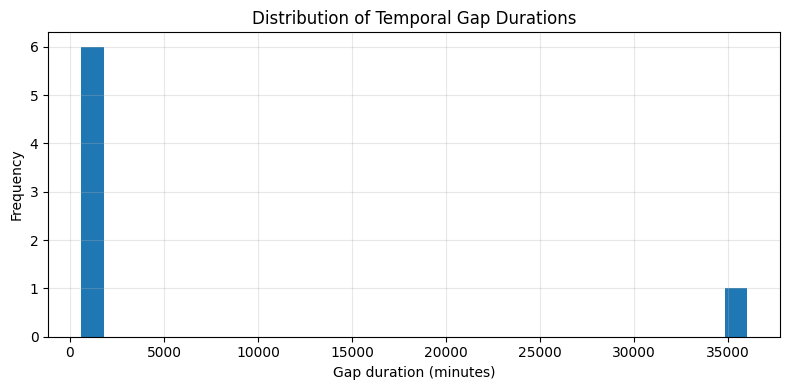

In [21]:
if n_gaps > 0:
    plt.figure(figsize=(8, 4))
    plt.hist(gaps.dt.total_seconds() / 60, bins=30)
    plt.xlabel("Gap duration (minutes)")
    plt.ylabel("Frequency")
    plt.title("Distribution of Temporal Gap Durations")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No gaps to plot.")

## 6. Data Quality Assessment

The Level-2 quality flag is binary:

- 0 → Bad or missing data
- 1 → Valid data

In [22]:
def load_variable(path, name):
    with xr.open_dataset(path, engine=NETCDF_ENGINE) as ds:
        return ds[name].values


quality_flags = np.concatenate(
    [load_variable(f, QUALITY_VAR) for f in files]
)

raw_components = {
    name: np.concatenate([load_variable(f, name) for f in files])
    for name in GSE_COMPONENTS
}

assert len(quality_flags) == len(time_utc)
assert all(len(values) == len(time_utc) for values in raw_components.values())

### 6.1 Definitive validity rule

Earlier drafts of this notebook used two inconsistent notions of
"valid" (a flag-only mask in some places, a flag-plus-fill mask in
others). A single, definitive validity rule is defined here and used
**everywhere downstream**:

```
valid =
    quality flag is valid
    AND
    no fill value
    AND
    finite numeric value
```

In [23]:
flag_valid_mask = quality_flags == QUALITY_VALID

fill_masks = {
    name: raw_components[name] == FILL_VALUE for name in GSE_COMPONENTS
}
no_fill_mask = np.logical_and.reduce(
    [~fill_masks[name] for name in GSE_COMPONENTS]
)

finite_mask = np.logical_and.reduce(
    [np.isfinite(raw_components[name]) for name in GSE_COMPONENTS]
)

valid_mask = flag_valid_mask & no_fill_mask & finite_mask

print(f"Flag-valid fraction:    {flag_valid_mask.mean():.4%}")
print(f"No-fill fraction:       {no_fill_mask.mean():.4%}")
print(f"Finite fraction:        {finite_mask.mean():.4%}")
print(f"Final valid fraction:   {valid_mask.mean():.4%}")

Flag-valid fraction:    96.4646%
No-fill fraction:       96.4646%
Finite fraction:        99.9794%
Final valid fraction:   96.4440%


### 6.2 Quality-flag distribution

In [24]:
unique_flags, flag_counts = np.unique(quality_flags, return_counts=True)

for flag, count in zip(unique_flags, flag_counts):
    print(f"{flag}: {count} ({count / len(quality_flags):.4%})")

0.0: 26446 (3.5354%)
1.0: 721591 (96.4646%)


### 6.3 Flag-valid vs. measurement-valid breakdown

A quality flag does not necessarily guarantee that every component
measurement is usable. The breakdown below distinguishes flag validity
from measurement validity (fill values, NaNs) and reports the final
usable fraction after combining both.

In [25]:
nan_mask = np.logical_or.reduce(
    [np.isnan(raw_components[name]) for name in GSE_COMPONENTS]
)
fill_any_mask = np.logical_or.reduce(
    [fill_masks[name] for name in GSE_COMPONENTS]
)

breakdown = pd.Series(
    {
        "Flag-valid %": flag_valid_mask.mean(),
        "Measurement-valid %": no_fill_mask.mean(),
        "Fill-value %": fill_any_mask.mean(),
        "NaN %": nan_mask.mean(),
        "Final usable %": valid_mask.mean(),
    }
)

breakdown.map(lambda x: f"{x:.4%}")

Flag-valid %           96.4646%
Measurement-valid %    96.4646%
Fill-value %            3.5354%
NaN %                   0.0206%
Final usable %         96.4440%
dtype: str

### 6.4 Valid-data fraction

In [26]:
print(f"Valid samples:   {np.count_nonzero(valid_mask)}")
print(f"Invalid samples: {np.count_nonzero(~valid_mask)}")
print(f"Valid fraction:  {valid_mask.mean():.4%}")

Valid samples:   721437
Invalid samples: 26600
Valid fraction:  96.4440%


### 6.5 Invalid-data intervals

Rather than only reporting the first/last invalid timestamp (which does
not measure interval duration), invalid samples are grouped into
contiguous runs, and each run's start, end, and duration are computed.

In [27]:
invalid_mask = ~valid_mask
n_invalid_samples = int(np.count_nonzero(invalid_mask))

# Identify contiguous runs of invalid samples via a change-point scan.
change_points = np.flatnonzero(np.diff(invalid_mask.astype(int)) != 0) + 1
run_bounds = np.concatenate(([0], change_points, [len(invalid_mask)]))

run_records = []
for run_start, run_end in zip(run_bounds[:-1], run_bounds[1:]):
    if invalid_mask[run_start]:
        run_records.append(
            {
                "run_start": time_utc[run_start],
                "run_end": time_utc[run_end - 1],
                "n_samples": run_end - run_start,
                "duration": time_utc[run_end - 1] - time_utc[run_start],
            }
        )

invalid_runs = pd.DataFrame(run_records)

n_invalid_runs = len(invalid_runs)
longest_invalid_run = (
    invalid_runs.loc[invalid_runs["duration"].idxmax()]
    if n_invalid_runs > 0
    else None
)

print(f"Individual invalid samples: {n_invalid_samples}")
print(f"Consecutive invalid runs:   {n_invalid_runs}")

if n_invalid_runs > 0:
    print(f"Longest invalid run:        {longest_invalid_run['duration']} "
          f"({longest_invalid_run['run_start']} to {longest_invalid_run['run_end']})")
    display(invalid_runs.sort_values("duration", ascending=False).head(10))
else:
    print("No invalid intervals present.")

Individual invalid samples: 26600
Consecutive invalid runs:   376
Longest invalid run:        0 days 12:00:00 (2026-07-14 12:00:00+00:00 to 2026-07-15 00:00:00+00:00)


,run_start,run_end,n_samples,duration
272,2026-07-14 12:00:00+00:00,2026-07-15 00:00:00+00:00,4321,0 days 12:00:00
3,2026-04-10 07:30:10+00:00,2026-04-10 09:09:50+00:00,599,0 days 01:39:40
268,2026-07-10 07:45:10+00:00,2026-07-10 08:14:50+00:00,179,0 days 00:29:40
120,2026-04-28 13:50:10+00:00,2026-04-28 14:09:50+00:00,119,0 days 00:19:40
251,2026-07-08 09:30:10+00:00,2026-07-08 09:49:50+00:00,119,0 days 00:19:40
290,2026-07-16 04:35:10+00:00,2026-07-16 04:54:50+00:00,119,0 days 00:19:40
128,2026-04-28 19:45:10+00:00,2026-04-28 20:04:50+00:00,119,0 days 00:19:40
0,2026-04-10 00:20:10+00:00,2026-04-10 00:34:50+00:00,89,0 days 00:14:40
360,2026-07-21 00:40:10+00:00,2026-07-21 00:54:50+00:00,89,0 days 00:14:40
138,2026-04-29 06:45:10+00:00,2026-04-29 06:59:50+00:00,89,0 days 00:14:40


### 6.6 Quality timeline

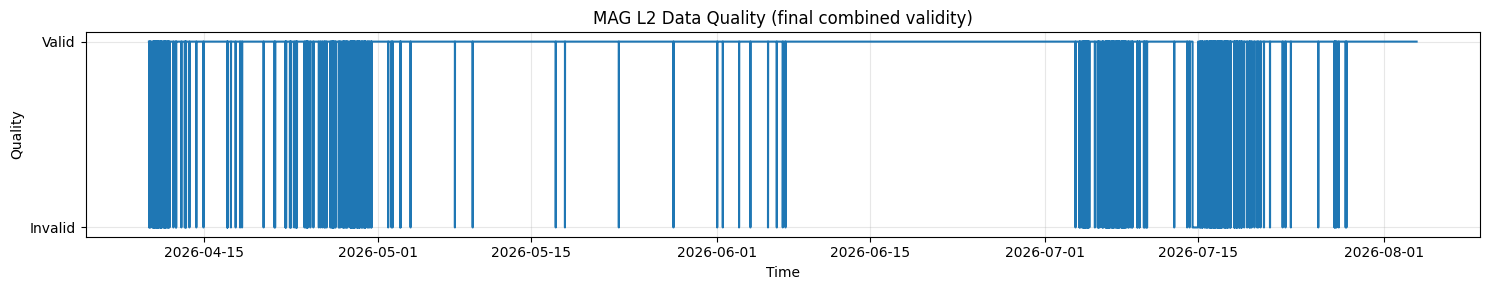

In [28]:
plt.figure(figsize=(15, 3))

plt.step(time_utc, valid_mask.astype(int), where="post")

plt.xlabel("Time")
plt.ylabel("Quality")
plt.yticks([0, 1], ["Invalid", "Valid"])
plt.title("MAG L2 Data Quality (final combined validity)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 6.7 Quality assessment summary

In [29]:
quality_summary = pd.Series(
    {
        "total_samples": len(quality_flags),
        "valid_samples": int(np.count_nonzero(valid_mask)),
        "invalid_samples": n_invalid_samples,
        "valid_fraction": valid_mask.mean(),
        "n_invalid_runs": n_invalid_runs,
        "longest_invalid_run": (
            longest_invalid_run["duration"] if n_invalid_runs > 0 else pd.Timedelta(0)
        ),
    }
)

quality_summary

total_samples                   748037
valid_samples                   721437
invalid_samples                  26600
valid_fraction                 0.96444
n_invalid_runs                     376
longest_invalid_run    0 days 12:00:00
dtype: object

## 7. Data Preparation

### 7.1 Apply the validity mask

The `valid_mask` defined in [6.1](#6.1-Definitive-validity-rule) already
combines the quality flag, fill-value check, and finiteness check, so it
is applied directly — no separate mask is recomputed here.

In [30]:
magnetic_field = {}

for name in GSE_COMPONENTS:
    values = raw_components[name].astype(float)
    values[~valid_mask] = np.nan
    magnetic_field[name] = values

for name, values in magnetic_field.items():
    residual_fill = np.count_nonzero(values == FILL_VALUE)
    print(f"{name}: {residual_fill} residual fill values after masking")

Bx_gse: 0 residual fill values after masking
By_gse: 0 residual fill values after masking
Bz_gse: 0 residual fill values after masking


### 7.2 Construct cleaned magnetic-field variables

In [31]:
mag_df = pd.DataFrame(magnetic_field, index=time_utc)
mag_df.index.name = "time"

mag_df.head()

,Bx_gse,By_gse,Bz_gse
time,,,
2026-04-10 00:00:00+00:00,3.743610,-3.871194,4.120170
2026-04-10 00:00:10+00:00,3.520511,-4.434005,3.669791
2026-04-10 00:00:20+00:00,3.735431,-4.193662,3.809150
2026-04-10 00:00:30+00:00,3.834646,-4.254137,3.996363
2026-04-10 00:00:40+00:00,3.875168,-4.059733,3.788136


## 8. Magnetic Field Components

Per-component statistics are calculated once, in
[8.1](#8.1-Component-statistics), rather than repeated per component —
avoiding the redundancy of separate `.describe()` calls for Bx, By, Bz.

### 8.1 Component statistics

Percentiles are included alongside the usual mean/std/min/max, since
percentiles are considerably more informative than min/max alone for
scientific sensor data.

In [32]:
component_stats = mag_df[GSE_COMPONENTS].describe(
    percentiles=[p / 100 for p in PERCENTILES]
).T

component_stats

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Bx_gse,721437.0,-3.775952,4.151825,-21.733215,-12.490399,-10.453086,-7.085850,-3.439675,-0.599854,2.682329,4.774059,35.633919
By_gse,721437.0,1.111016,4.549629,-17.368238,-9.474919,-5.713885,-2.078166,0.885860,4.398674,7.837331,14.153240,28.379330
Bz_gse,721437.0,-2.339217,3.676002,-21.166954,-11.817807,-8.157744,-4.537401,-2.423574,-0.071198,3.553146,7.026021,21.913595


### 8.2 Component-wise valid fractions

A passing quality flag does not guarantee every component is usable, so
each component's own valid fraction is reported explicitly.

In [33]:
component_valid_records = []
for name in GSE_COMPONENTS:
    total = len(raw_components[name])
    valid = int(np.count_nonzero(valid_mask))
    invalid = total - valid
    component_valid_records.append(
        {
            "component": name,
            "total": total,
            "valid": valid,
            "invalid": invalid,
            "valid_%": valid / total,
        }
    )

component_valid_summary = pd.DataFrame(component_valid_records).set_index("component")
component_valid_summary

,total,valid,invalid,valid_%
component,,,,
Bx_gse,748037,721437,26600,0.96444
By_gse,748037,721437,26600,0.96444
Bz_gse,748037,721437,26600,0.96444


### 8.3 Component distributions

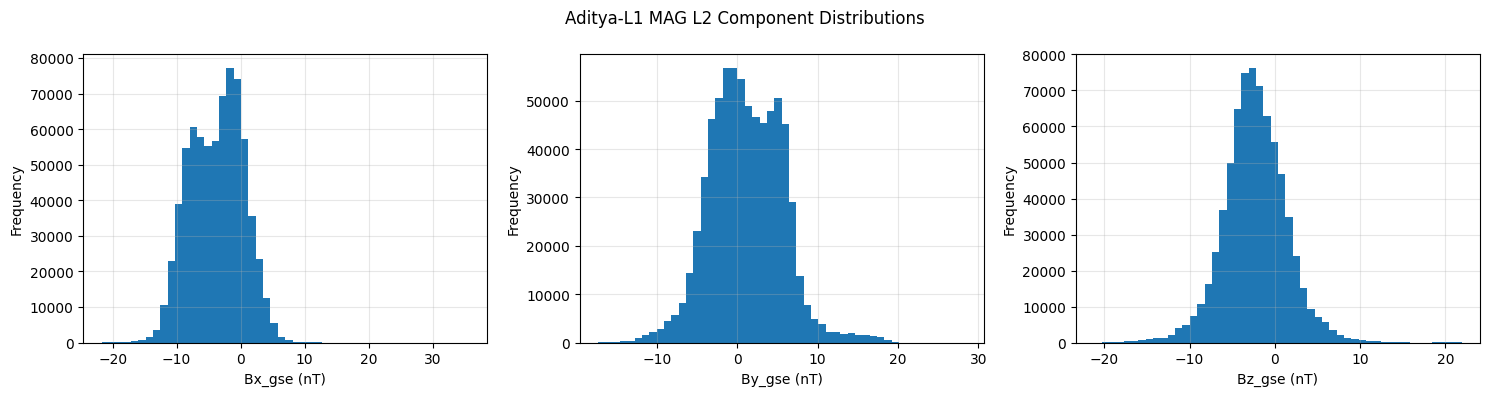

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, name in zip(axes, GSE_COMPONENTS):
    ax.hist(mag_df[name].dropna(), bins=50)
    ax.set_xlabel(f"{name} (nT)")
    ax.set_ylabel("Frequency")
    ax.grid(alpha=0.3)

fig.suptitle("Aditya-L1 MAG L2 Component Distributions")
plt.tight_layout()
plt.show()

### 8.4 Component correlations

In [35]:
component_corr = mag_df[GSE_COMPONENTS].corr()
component_corr

,Bx_gse,By_gse,Bz_gse
Bx_gse,1.000000,-0.499719,0.020929
By_gse,-0.499719,1.000000,0.022801
Bz_gse,0.020929,0.022801,1.000000


### 8.5 Component time series

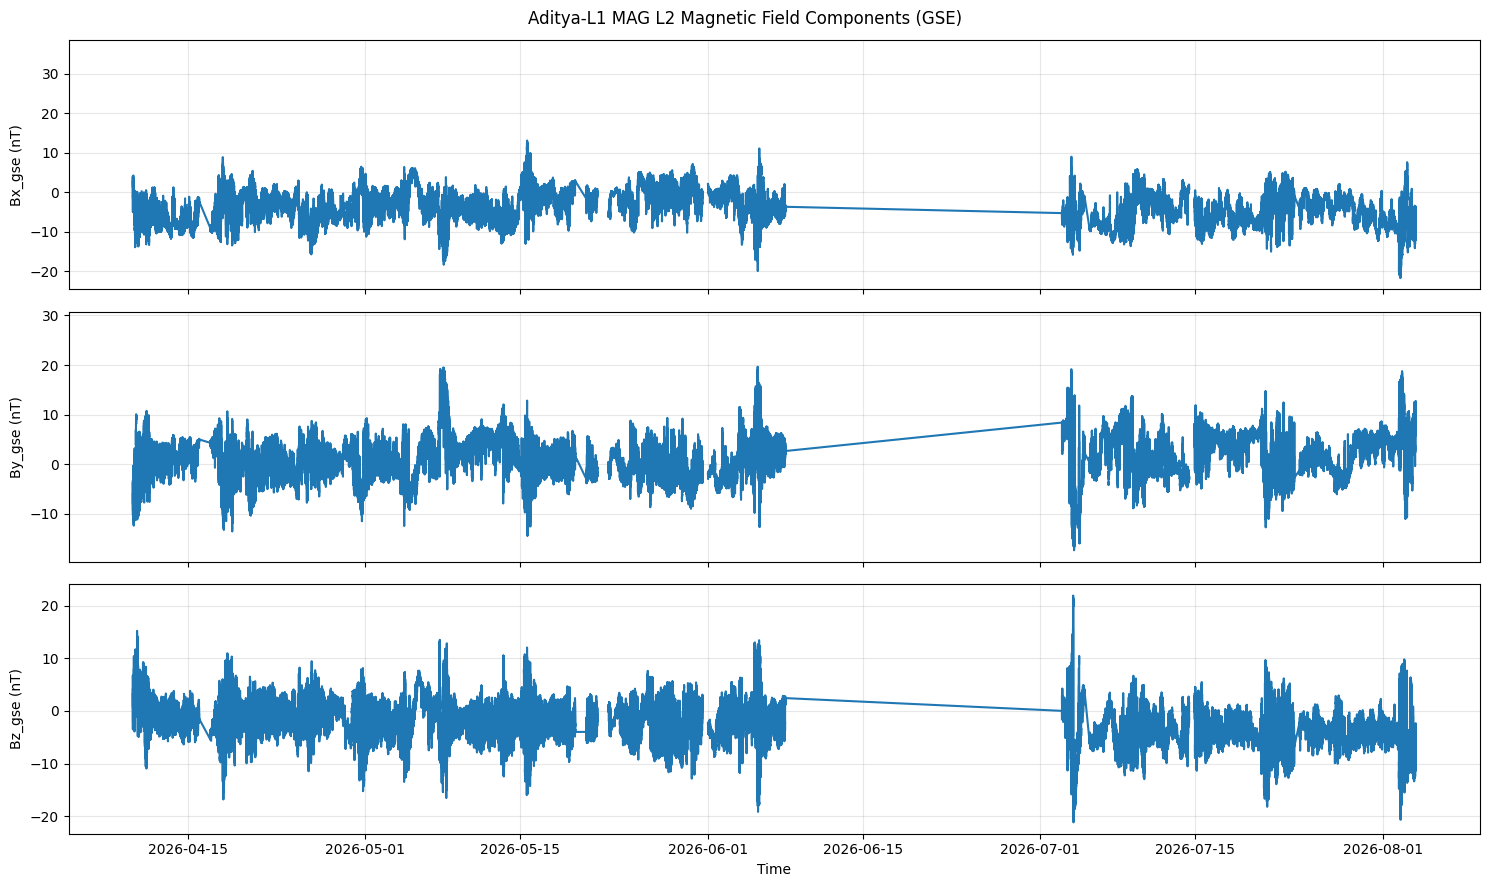

In [36]:
fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)

for ax, component in zip(axes, GSE_COMPONENTS):
    ax.plot(mag_df.index, mag_df[component])
    ax.set_ylabel(f"{component} (nT)")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time")
fig.suptitle("Aditya-L1 MAG L2 Magnetic Field Components (GSE)")
plt.tight_layout()
plt.show()

## 9. Magnetic Field Magnitude

### 9.1 Calculate |B|

In [37]:
mag_df["B_mag"] = np.sqrt(
    mag_df["Bx_gse"] ** 2
    + mag_df["By_gse"] ** 2
    + mag_df["Bz_gse"] ** 2
)

### 9.2 |B| time series

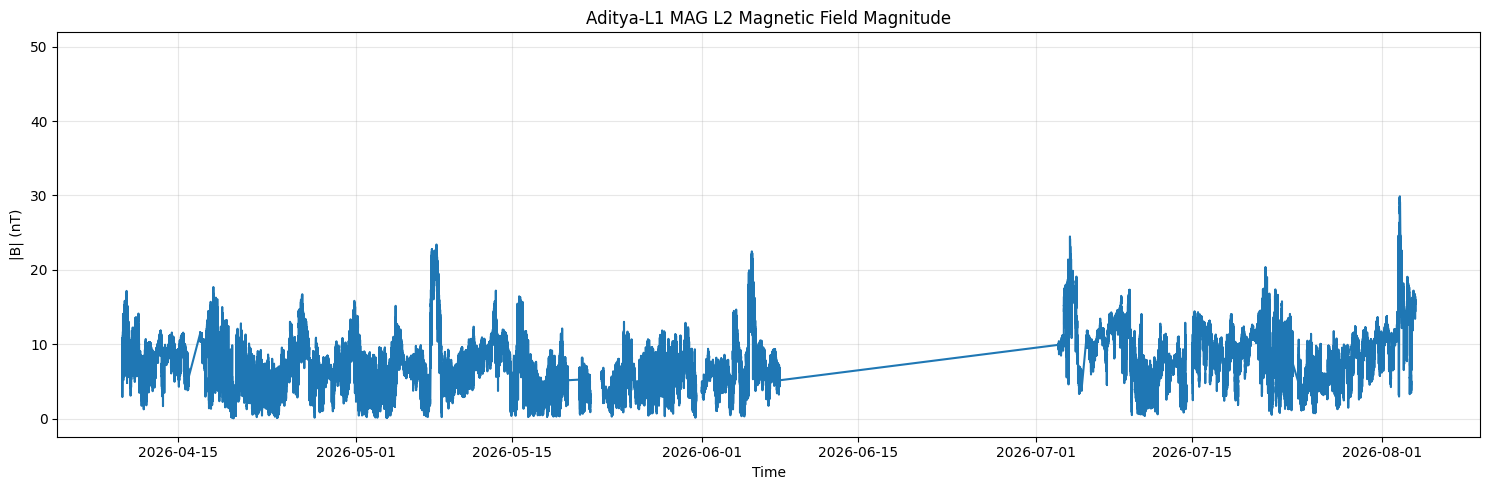

In [38]:
plt.figure(figsize=(15, 5))

plt.plot(mag_df.index, mag_df["B_mag"])

plt.xlabel("Time")
plt.ylabel("|B| (nT)")
plt.title("Aditya-L1 MAG L2 Magnetic Field Magnitude")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 9.3 |B| statistics

In [39]:
valid_B = mag_df["B_mag"].dropna()

print(f"Valid observations: {len(valid_B)}")
print(f"Mean:   {valid_B.mean():.3f} nT")
print(f"Std:    {valid_B.std():.3f} nT")
print(f"Median: {valid_B.median():.3f} nT")
print(f"Min:    {valid_B.min():.3f} nT")
print(f"Max:    {valid_B.max():.3f} nT")

Valid observations: 721437
Mean:   7.643 nT
Std:    3.742 nT
Median: 7.291 nT
Min:    0.034 nT
Max:    49.466 nT


### 9.4 |B| distribution

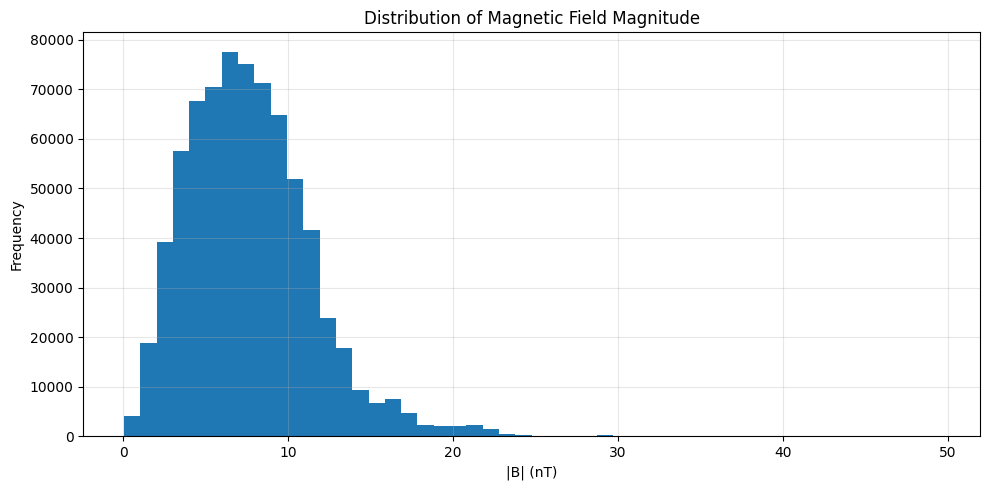

In [40]:
plt.figure(figsize=(10, 5))

plt.hist(valid_B, bins=50)

plt.xlabel("|B| (nT)")
plt.ylabel("Frequency")
plt.title("Distribution of Magnetic Field Magnitude")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 9.5 Percentile analysis

In [41]:
percentile_values = np.percentile(valid_B, PERCENTILES)

percentile_table = pd.Series(
    percentile_values,
    index=[f"p{p}" for p in PERCENTILES],
    name="B_mag (nT)",
)

percentile_table

p1      1.276824
p5      2.389227
p25     4.874642
p50     7.291377
p75     9.833332
p95    14.162038
p99    19.513761
Name: B_mag (nT), dtype: float64

## 10. Characterization Summary

### 10.1 Dataset characterization summary

A single table consolidating the key metrics from every section above —
the fastest way to get a picture of the dataset without reading the full
notebook.

In [42]:
summary_table = pd.DataFrame(
    [
        ("Coverage", "Files", f"{len(files)}"),
        ("Coverage", "Start", f"{time_utc[0]}"),
        ("Coverage", "End", f"{time_utc[-1]}"),
        ("Coverage", "Duration", f"{time_utc[-1] - time_utc[0]}"),
        ("Sampling", "Nominal cadence", f"{NOMINAL_CADENCE}"),
        ("Sampling", "Median cadence", f"{median_cadence}"),
        ("Sampling", "Temporal gaps", f"{n_gaps} (total {total_gap_duration})"),
        ("Quality", "Valid", f"{valid_mask.mean():.2%}"),
        ("Quality", "Fill values", f"{fill_any_mask.mean():.2%}"),
        ("Quality", "Final usable", f"{valid_mask.mean():.2%}"),
        ("Field", "Median |B|", f"{valid_B.median():.3f} nT"),
        ("Field", "Mean |B|", f"{valid_B.mean():.3f} nT"),
        ("Field", "P99 |B|", f"{np.percentile(valid_B, 99):.3f} nT"),
    ],
    columns=["Category", "Metric", "Value"],
)

summary_table

,Category,Metric,Value
0,Coverage,Files,91
1,Coverage,Start,2026-04-10 00:00:00+00:00
2,Coverage,End,2026-08-03 23:59:50+00:00
3,Coverage,Duration,115 days 23:59:50
4,Sampling,Nominal cadence,0 days 00:00:10
5,Sampling,Median cadence,0 days 00:00:10
6,Sampling,Temporal gaps,7 (total 29 days 10:08:20)
7,Quality,Valid,96.44%
8,Quality,Fill values,3.54%
9,Quality,Final usable,96.44%


### 10.2 Temporal characteristics

In [43]:
temporal_summary = pd.Series(
    {
        "start": time_utc[0],
        "end": time_utc[-1],
        "duration": time_utc[-1] - time_utc[0],
        "n_files": len(files),
        "n_samples": len(time_utc),
        "nominal_cadence": NOMINAL_CADENCE,
        "median_cadence": median_cadence,
        "pct_at_nominal_cadence": pct_at_nominal,
        "n_gaps": n_gaps,
        "median_gap_duration": median_gap_duration,
        "max_gap_duration": max_gap_duration,
        "total_gap_duration": total_gap_duration,
        "pct_period_affected_by_gaps": pct_period_affected,
    }
)

temporal_summary

start                          2026-04-10 00:00:00+00:00
end                            2026-08-03 23:59:50+00:00
duration                               115 days 23:59:50
n_files                                               91
n_samples                                         748037
nominal_cadence                          0 days 00:00:10
median_cadence                           0 days 00:00:10
pct_at_nominal_cadence                          0.999991
n_gaps                                                 7
median_gap_duration                      1 days 00:00:00
max_gap_duration                        25 days 00:00:10
total_gap_duration                      29 days 10:08:20
pct_period_affected_by_gaps                     0.253642
dtype: object

### 10.3 Data-quality characteristics

In [44]:
quality_char_summary = pd.Series(
    {
        "valid_fraction": valid_mask.mean(),
        "n_invalid_samples": n_invalid_samples,
        "n_invalid_runs": n_invalid_runs,
        "longest_invalid_run": (
            longest_invalid_run["duration"] if n_invalid_runs > 0 else pd.Timedelta(0)
        ),
        "fill_value_fraction": fill_any_mask.mean(),
    }
)

quality_char_summary

valid_fraction                 0.96444
n_invalid_samples                26600
n_invalid_runs                     376
longest_invalid_run    0 days 12:00:00
fill_value_fraction           0.035354
dtype: object

### 10.4 Magnetic-field characteristics

In [45]:
field_char_summary = pd.DataFrame(
    {
        "mean_nT": mag_df[GSE_COMPONENTS + ["B_mag"]].mean(),
        "std_nT": mag_df[GSE_COMPONENTS + ["B_mag"]].std(),
        "min_nT": mag_df[GSE_COMPONENTS + ["B_mag"]].min(),
        "median_nT": mag_df[GSE_COMPONENTS + ["B_mag"]].median(),
        "p99_nT": mag_df[GSE_COMPONENTS + ["B_mag"]].quantile(0.99),
        "max_nT": mag_df[GSE_COMPONENTS + ["B_mag"]].max(),
    }
)

field_char_summary

,mean_nT,std_nT,min_nT,median_nT,p99_nT,max_nT
Bx_gse,-3.775952,4.151825,-21.733215,-3.439675,4.774059,35.633919
By_gse,1.111016,4.549629,-17.368238,0.885860,14.153240,28.379330
Bz_gse,-2.339217,3.676002,-21.166954,-2.423574,7.026021,21.913595
B_mag,7.642834,3.741779,0.034136,7.291377,19.513761,49.466420


### 10.5 Important observations

The statements below are generated directly from the quantities computed
above, rather than written as generic prose.

In [46]:
print(
    f"The dataset contains {len(time_utc)} observations across {len(files)} files, "
    f"spanning {time_utc[0]} to {time_utc[-1]} ({time_utc[-1] - time_utc[0]})."
)
print(
    f"Approximately {valid_mask.mean():.2%} of samples pass the combined validity "
    f"criterion (quality flag, no fill value, finite value)."
)
print(
    f"The dominant sampling interval is {mode_cadence}, matched by "
    f"{pct_at_nominal:.2%} of intervals; {n_non_nominal} intervals are non-nominal."
)
if n_gaps > 0:
    print(
        f"There are {n_gaps} gaps exceeding {GAP_THRESHOLD}, the largest being "
        f"{max_gap_duration}, together accounting for {pct_period_affected:.4%} "
        f"of the observation period."
    )
else:
    print(f"No gaps exceeding {GAP_THRESHOLD} were found.")
print(f"The median magnetic-field magnitude is {valid_B.median():.3f} nT "
      f"(mean {valid_B.mean():.3f} nT, P99 {np.percentile(valid_B, 99):.3f} nT).")

The dataset contains 748037 observations across 91 files, spanning 2026-04-10 00:00:00+00:00 to 2026-08-03 23:59:50+00:00 (115 days 23:59:50).
Approximately 96.44% of samples pass the combined validity criterion (quality flag, no fill value, finite value).
The dominant sampling interval is 0 days 00:00:10, matched by 100.00% of intervals; 7 intervals are non-nominal.
There are 7 gaps exceeding 0 days 00:00:50, the largest being 25 days 00:00:10, together accounting for 25.3642% of the observation period.
The median magnetic-field magnitude is 7.291 nT (mean 7.643 nT, P99 19.514 nT).


### 10.6 Limitations

- This characterization uses GSE components as the primary basis; GSM
  components are inventoried but not statistically characterized here.
- Gap detection is based on a fixed multiple of the nominal cadence and
  may not capture sub-cadence data quality issues.
- File-level metadata is inspected from a single representative file and
  assumed representative of all files in the dataset.
- Invalid-run detection operates on the combined `valid_mask` and does
  not separately report runs attributable only to the quality flag versus
  only to fill values.

## 11. Conclusions

### 11.1 Key findings

In [47]:
print(f"1. Dataset coverage:      {len(files)} files, {len(time_utc)} samples, "
      f"{time_utc[0]} to {time_utc[-1]} ({time_utc[-1] - time_utc[0]}).")
print(f"2. Sampling:              nominal {NOMINAL_CADENCE}, "
      f"{pct_at_nominal:.2%} of intervals at nominal cadence, "
      f"{n_gaps} gap(s) exceeding {GAP_THRESHOLD}.")
print(f"3. Data quality:          {valid_mask.mean():.2%} of samples pass the "
      f"combined validity criterion; {n_invalid_runs} invalid run(s), "
      f"longest {longest_invalid_run['duration'] if n_invalid_runs > 0 else pd.Timedelta(0)}.")
print(f"4. Magnetic field:        median |B| = {valid_B.median():.3f} nT, "
      f"range [{valid_B.min():.3f}, {valid_B.max():.3f}] nT, "
      f"consistent with expected interplanetary field behavior.")
print("5. Major limitations:     see Section 10.6 (GSM not statistically "
      "characterized; gap/metadata assumptions noted).")

1. Dataset coverage:      91 files, 748037 samples, 2026-04-10 00:00:00+00:00 to 2026-08-03 23:59:50+00:00 (115 days 23:59:50).
2. Sampling:              nominal 0 days 00:00:10, 100.00% of intervals at nominal cadence, 7 gap(s) exceeding 0 days 00:00:50.
3. Data quality:          96.44% of samples pass the combined validity criterion; 376 invalid run(s), longest 0 days 12:00:00.
4. Magnetic field:        median |B| = 7.291 nT, range [0.034, 49.466] nT, consistent with expected interplanetary field behavior.
5. Major limitations:     see Section 10.6 (GSM not statistically characterized; gap/metadata assumptions noted).


### 11.2 Readiness for downstream analysis

Following the quality masking applied in Section 7 (using the single
definitive validity rule from Section 6.1), the cleaned magnetic-field
variables (`mag_df`) are suitable for use in downstream scientific
analysis, subject to the limitations noted in Section 10.6.